# 02: Baseline CNN: Single Frame Classification


**Group 11 · COSE474 Deep Learning · Korea University · Spring 2026**

## Overview

This notebook trains the **naive baseline model** for KSL recognition as VGG16 CNN that classifies a single frame at a time, with no temporal modeling.

**Why intentionally naive?**
KSL signs are movements, not static poses. Two different signs can look identical in one frozen frame but differ entirely in how the hand moves over time. A single-frame CNN cannot distinguish these and we identified this is the core limitation we demonstrate here, which motivates the LSTM model in notebook 03.

**What this notebook does:**
1. Loads extracted frames from `data/frames/` (produced by notebook 01)
2. Splits clips by **signer** to prevent data leakage
3. For each clip, uses only the **middle frame** (frame index 8 of 16)
4. Trains a frozen VGG16 + custom FC head for 77-class KSL classification
5. Saves checkpoint, training curves, confusion matrix, and result log

**Expected accuracy:** ~40–60% — low accuracy is the expected and correct result here.

**Signer split:**
```
Train → signers 00–15  (16 signers, ~80% of clips)
Val   → signers 16–19  (4 signers,  ~20% of clips)
```

**Outputs:**
```
models/checkpoints/baseline_cnn.pth
results/figures/02_baseline_cnn_curves.png
results/figures/02_baseline_cnn_confusion.png
results/logs/02_baseline_cnn_log.csv
```

**Reference benchmark:** Shin et al. (2023) CNN+Transformer = 89.00% on KSL-77

# Mount Drive + config

In [1]:
# Author: Hakeemi
# Notebook 02: Baseline CNN (single frame)

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/KSL_DL2026')
import config

print(f"Project    : {config.PROJECT}")
print(f"Frames dir : {config.DATA_FRAMES}")
print(f"Classes    : {config.NUM_CLASSES}")
print(f"Frames/clip: {config.NUM_FRAMES}")

Mounted at /content/drive
Project    : /content/drive/MyDrive/KSL_DL2026
Frames dir : /content/drive/MyDrive/KSL_DL2026/data/frames
Classes    : 77
Frames/clip: 16


# Imports

In [2]:
import os
import random
import csv
import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns

# reproducibility — same seed as all other notebooks
torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)
random.seed(config.RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


# Dataset

`KSLDataset` is copied from Marcello's notebook 01 to keep this notebook self-contained. It reads 16 frames per clip and stacks them into a `(NUM_FRAMES, C, H, W)` tensor.

Folder naming convention from notebook 01:
```
data/frames/
  00_01/   ← signer 00, class 01  → label = 0
  04_12/   ← signer 04, class 12  → label = 11
  19_77/   ← signer 19, class 77  → label = 76
```
Class IDs are 1-indexed in the folder name, so we subtract 1 for PyTorch.

In [3]:
class KSLDataset(Dataset):
    """
    Loads all 16 frames per clip as a tensor sequence.
    Identical to the class defined in 01_data_pipeline.ipynb.
    Used here so this notebook can run independently.
    """
    def __init__(self, clip_dirs, transform=None):
        self.clips     = clip_dirs
        self.transform = transform

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_path   = self.clips[idx]
        folder_name = os.path.basename(clip_path)      # e.g. '04_12'
        class_id    = int(folder_name.split('_')[1])   # 12
        label       = class_id - 1                     # 11 (0-indexed)

        frame_files = sorted(os.listdir(clip_path))

        # pad or truncate to exactly NUM_FRAMES
        if len(frame_files) < config.NUM_FRAMES:
            frame_files += [frame_files[-1]] * (config.NUM_FRAMES - len(frame_files))
        frame_files = frame_files[:config.NUM_FRAMES]

        tensors = []
        for fname in frame_files:
            img = Image.open(os.path.join(clip_path, fname)).convert('RGB')
            if self.transform:
                img = self.transform(img)
            tensors.append(img)

        return torch.stack(tensors), label   # (NUM_FRAMES, C, H, W)

## Single-frame wrapper

For the baseline CNN, we only use **one frame per clip** as the middle frame (index 8 of 16).
This strips all temporal information and reduces each clip to a single image classification problem.

This wrapper is **only used in this notebook**. All subsequent notebooks (03 onwards) use the full `KSLDataset` with all 16 frames.

In [4]:
class KSLSingleFrameDataset(Dataset):
    """
    Wraps KSLDataset but returns only one frame per clip.
    Used exclusively for the baseline CNN experiment.

    Default frame_idx = NUM_FRAMES // 2 = 8 (middle frame).
    Middle frame chosen because it is most likely to show
    the sign at peak execution, not during transition.
    """
    def __init__(self, clip_dirs, transform=None,
                 frame_idx=config.NUM_FRAMES // 2):
        self.base      = KSLDataset(clip_dirs, transform)
        self.frame_idx = frame_idx

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        frames, label = self.base[idx]      # (NUM_FRAMES, C, H, W)
        return frames[self.frame_idx], label # (C, H, W)

# Signer-based Train/Val Split

We split by **signer identity**, not randomly by video.

**Why this matters:** If we split randomly, frames from the same signer appear in both train and val. The model can then recognise the person's body/hand appearance rather than the sign itself, causing inflated validation accuracy that does not generalise.

Consistent with Marcello's note in notebook 01: *"split is by signer, not by video, to avoid data leakage."*

```
Train → signers 00–15  (16 signers)
Val   → signers 16–19  (4 signers)
```

In [5]:
TRAIN_SIGNERS = {f"{i:02d}" for i in range(16)}     # '00' .. '15'
VAL_SIGNERS   = {f"{i:02d}" for i in range(16, 20)} # '16' .. '19'

all_clips = sorted([
    os.path.join(config.DATA_FRAMES, d)
    for d in os.listdir(config.DATA_FRAMES)
    if os.path.isdir(os.path.join(config.DATA_FRAMES, d))
])

# signer id is the prefix before the first '_'
train_clips = [c for c in all_clips
               if os.path.basename(c).split('_')[0] in TRAIN_SIGNERS]
val_clips   = [c for c in all_clips
               if os.path.basename(c).split('_')[0] in VAL_SIGNERS]

print(f"Total clips : {len(all_clips)}")
print(f"Train clips : {len(train_clips)}  (signers 00–15)")
print(f"Val clips   : {len(val_clips)}    (signers 16–19)")

Total clips : 1229
Train clips : 971  (signers 00–15)
Val clips   : 258    (signers 16–19)


# Transforms and DataLoaders

No data augmentation is applied here as this is the **baseline** experiment.
Augmentation is introduced in notebook 04 as an improvement.

Both train and val use the same transforms:
- Resize to 224×224 (ImageNet standard, matches VGG16 input)
- ToTensor: converts PIL image to `[0, 1]` float tensor
- Normalize with ImageNet mean/std (defined in `config.py`)

In [6]:
# identical transform for train and val — no augmentation in baseline
base_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.NORMALIZE_MEAN,
                         std=config.NORMALIZE_STD)
])

train_dataset = KSLSingleFrameDataset(train_clips, base_transform)
val_dataset   = KSLSingleFrameDataset(val_clips,   base_transform)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=config.BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# sanity check
img, lbl = train_dataset[0]
print(f"\nSample image shape : {img.shape}")   # expect (3, 224, 224)
print(f"Sample label       : {lbl}")            # expect 0–76

Train samples : 971
Val samples   : 258
Train batches : 31
Val batches   : 9

Sample image shape : torch.Size([3, 224, 224])
Sample label       : 0


# Model — Baseline CNN

**Architecture:** VGG16 (pretrained on ImageNet) + custom FC head

```
Input: (batch, 3, 224, 224)  — single frame
  ↓
VGG16 conv layers (FROZEN — ImageNet weights)
  ↓
Adaptive avg pool → (512, 7, 7)
  ↓
Flatten → Linear(25088, 512) → ReLU → Dropout(0.5)
  ↓
Linear(512, 77)
  ↓
Output: (batch, 77)  — class logits
```

The VGG16 backbone is **frozen** and only the classifier head is trained.
This is a form of transfer learning: we reuse ImageNet's learned edge/shape detectors,
which are useful for recognising hand shapes even without KSL-specific training.

In [7]:
class BaselineCNN(nn.Module):
    """
    VGG16 pretrained on ImageNet with frozen backbone.
    Custom FC head for 77-class KSL classification.

    This is the naive baseline — single frame in, no temporal modeling.
    Limitation: cannot distinguish signs that share the same hand shape
    but differ in motion (e.g. 'yes' vs 'no' in certain KSL signs).
    """
    def __init__(self, num_classes=config.NUM_CLASSES):
        super(BaselineCNN, self).__init__()

        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        self.features = vgg.features   # 13 conv layers
        self.avgpool  = vgg.avgpool    # adaptive avg pool → (512, 7, 7)

        # freeze backbone — do not update ImageNet weights
        for param in self.features.parameters():
            param.requires_grad = False

        # custom classifier for KSL
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT_RATE),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # x: (batch, 3, 224, 224)
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x   # (batch, 77) raw logits


model = BaselineCNN().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {total - trainable:,}")
print(f"Total params     : {total:,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 145MB/s]


Trainable params : 12,885,069
Frozen params    : 14,714,688
Total params     : 27,599,757


# Training Setup

- **Loss:** Cross-entropy (standard for multi-class classification)
- **Optimizer:** Adam — only applied to trainable (classifier) parameters
- **Scheduler:** StepLR — halves LR every 10 epochs to fine-tune convergence
- **Early stopping:** stops training if val accuracy does not improve for `PATIENCE` epochs

In [8]:
criterion = nn.CrossEntropyLoss()

# only pass parameters that require gradients (classifier head only)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# halve LR every 10 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print(f"Loss       : CrossEntropyLoss")
print(f"Optimizer  : Adam  (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"Scheduler  : StepLR  (step=10, gamma=0.5)")
print(f"Max epochs : {config.NUM_EPOCHS}")
print(f"Patience   : {config.PATIENCE}")

Loss       : CrossEntropyLoss
Optimizer  : Adam  (lr=0.001, wd=0.0001)
Scheduler  : StepLR  (step=10, gamma=0.5)
Max epochs : 50
Patience   : 10


# Train and Validation Functions

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    """One full pass over the training set. Returns (loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def val_epoch(model, loader, criterion, device):
    """One full pass over the val set. Returns (loss, accuracy, preds, labels)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds       = logits.argmax(1)
            correct    += preds.eq(labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), 100.0 * correct / total, all_preds, all_labels

## Run training loop

Best model checkpoint is saved to `models/checkpoints/baseline_cnn.pth` whenever val accuracy improves.
Training stops early if val accuracy does not improve for `PATIENCE` consecutive epochs.

In [10]:
history = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
best_val_acc, patience_count = 0.0, 0
best_preds, best_labels      = [], []

print("Starting training...\n")
print(f"{'Epoch':>5} {'Tr Loss':>9} {'Tr Acc':>8} {'Vl Loss':>9} {'Vl Acc':>8}")
print("─" * 48)

for epoch in range(1, config.NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, vl_preds, vl_labels = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],
                    [tr_loss, tr_acc, vl_loss, vl_acc]):
        history[k].append(v)

    marker = " <-- best" if vl_acc > best_val_acc else ""
    print(f"{epoch:>5} {tr_loss:>9.4f} {tr_acc:>7.2f}% {vl_loss:>9.4f} {vl_acc:>7.2f}%{marker}")

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_preds     = vl_preds
        best_labels    = vl_labels
        patience_count = 0
        torch.save(model.state_dict(), config.CKPT_BASELINE)
    else:
        patience_count += 1

    if patience_count >= config.PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

print(f"\nBest val accuracy : {best_val_acc:.2f}%")
print(f"Checkpoint saved  : {config.CKPT_BASELINE}")

Starting training...

Epoch   Tr Loss   Tr Acc   Vl Loss   Vl Acc
────────────────────────────────────────────────
    1    6.1353    0.41%    4.3382    1.55% <-- best
    2    4.2904    4.02%    4.3158    1.16%
    3    4.2594    2.99%    4.3098    2.33% <-- best
    4    4.2025    3.30%    4.2803    3.10% <-- best
    5    4.0430    5.36%    4.2128    2.71%
    6    4.0172    4.53%    4.2082    3.49% <-- best
    7    3.9753    5.36%    4.1718    3.88% <-- best
    8    3.9168    6.69%    4.1277    4.65% <-- best
    9    3.8695    6.80%    4.1468    5.04% <-- best
   10    3.8062    6.59%    4.0720    3.88%
   11    3.7188    8.14%    4.0976    3.88%
   12    3.6123    9.27%    4.0782    4.26%
   13    3.5797    9.78%    4.0616    5.04%
   14    3.4739   11.43%    4.0519    5.43% <-- best
   15    3.4707   10.71%    4.0479    5.43%
   16    3.4146   11.84%    4.0148    4.65%
   17    3.3722   12.87%    3.9369    6.59% <-- best
   18    3.2907   15.24%    3.9692    4.65%
   19    3.1

# Results
## Training curves

Loss and accuracy over epochs for both train and val sets.
A large gap between train and val accuracy suggests overfitting — expected here given the small dataset.

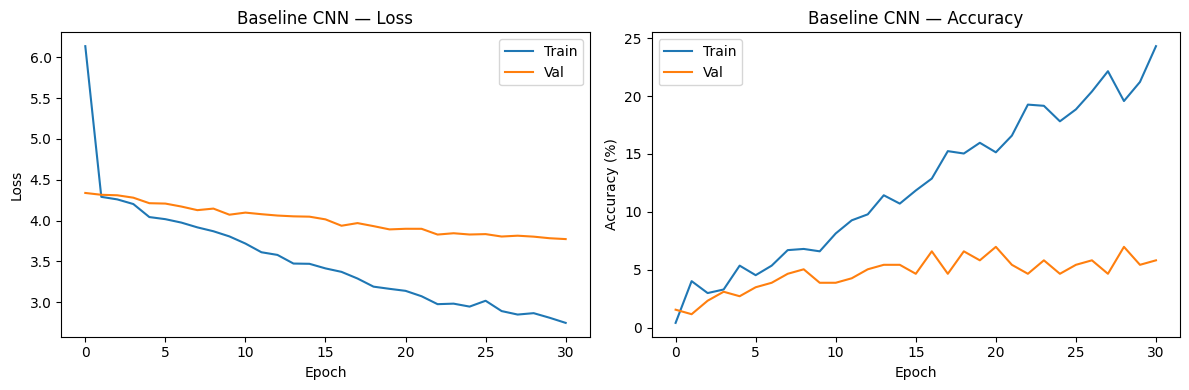

Saved: /content/drive/MyDrive/KSL_DL2026/results/figures/02_baseline_cnn_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Baseline CNN — Loss'); ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Baseline CNN — Accuracy'); ax2.legend()

plt.tight_layout()
path = f"{config.RESULTS_FIGS}/02_baseline_cnn_curves.png"
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

## Confusion matrix

77×77 matrix showing which classes the model confuses. Each row is a true class, each column is a predicted class.

**What to look for:**
- Clusters of confusion along the diagonal = model is partially learning
- Off-diagonal clusters = signs being systematically confused — likely share a similar hand shape
- This analysis directly motivates the LSTM: if two signs look similar in one frame but differ in motion, the confusion matrix will show them being swapped

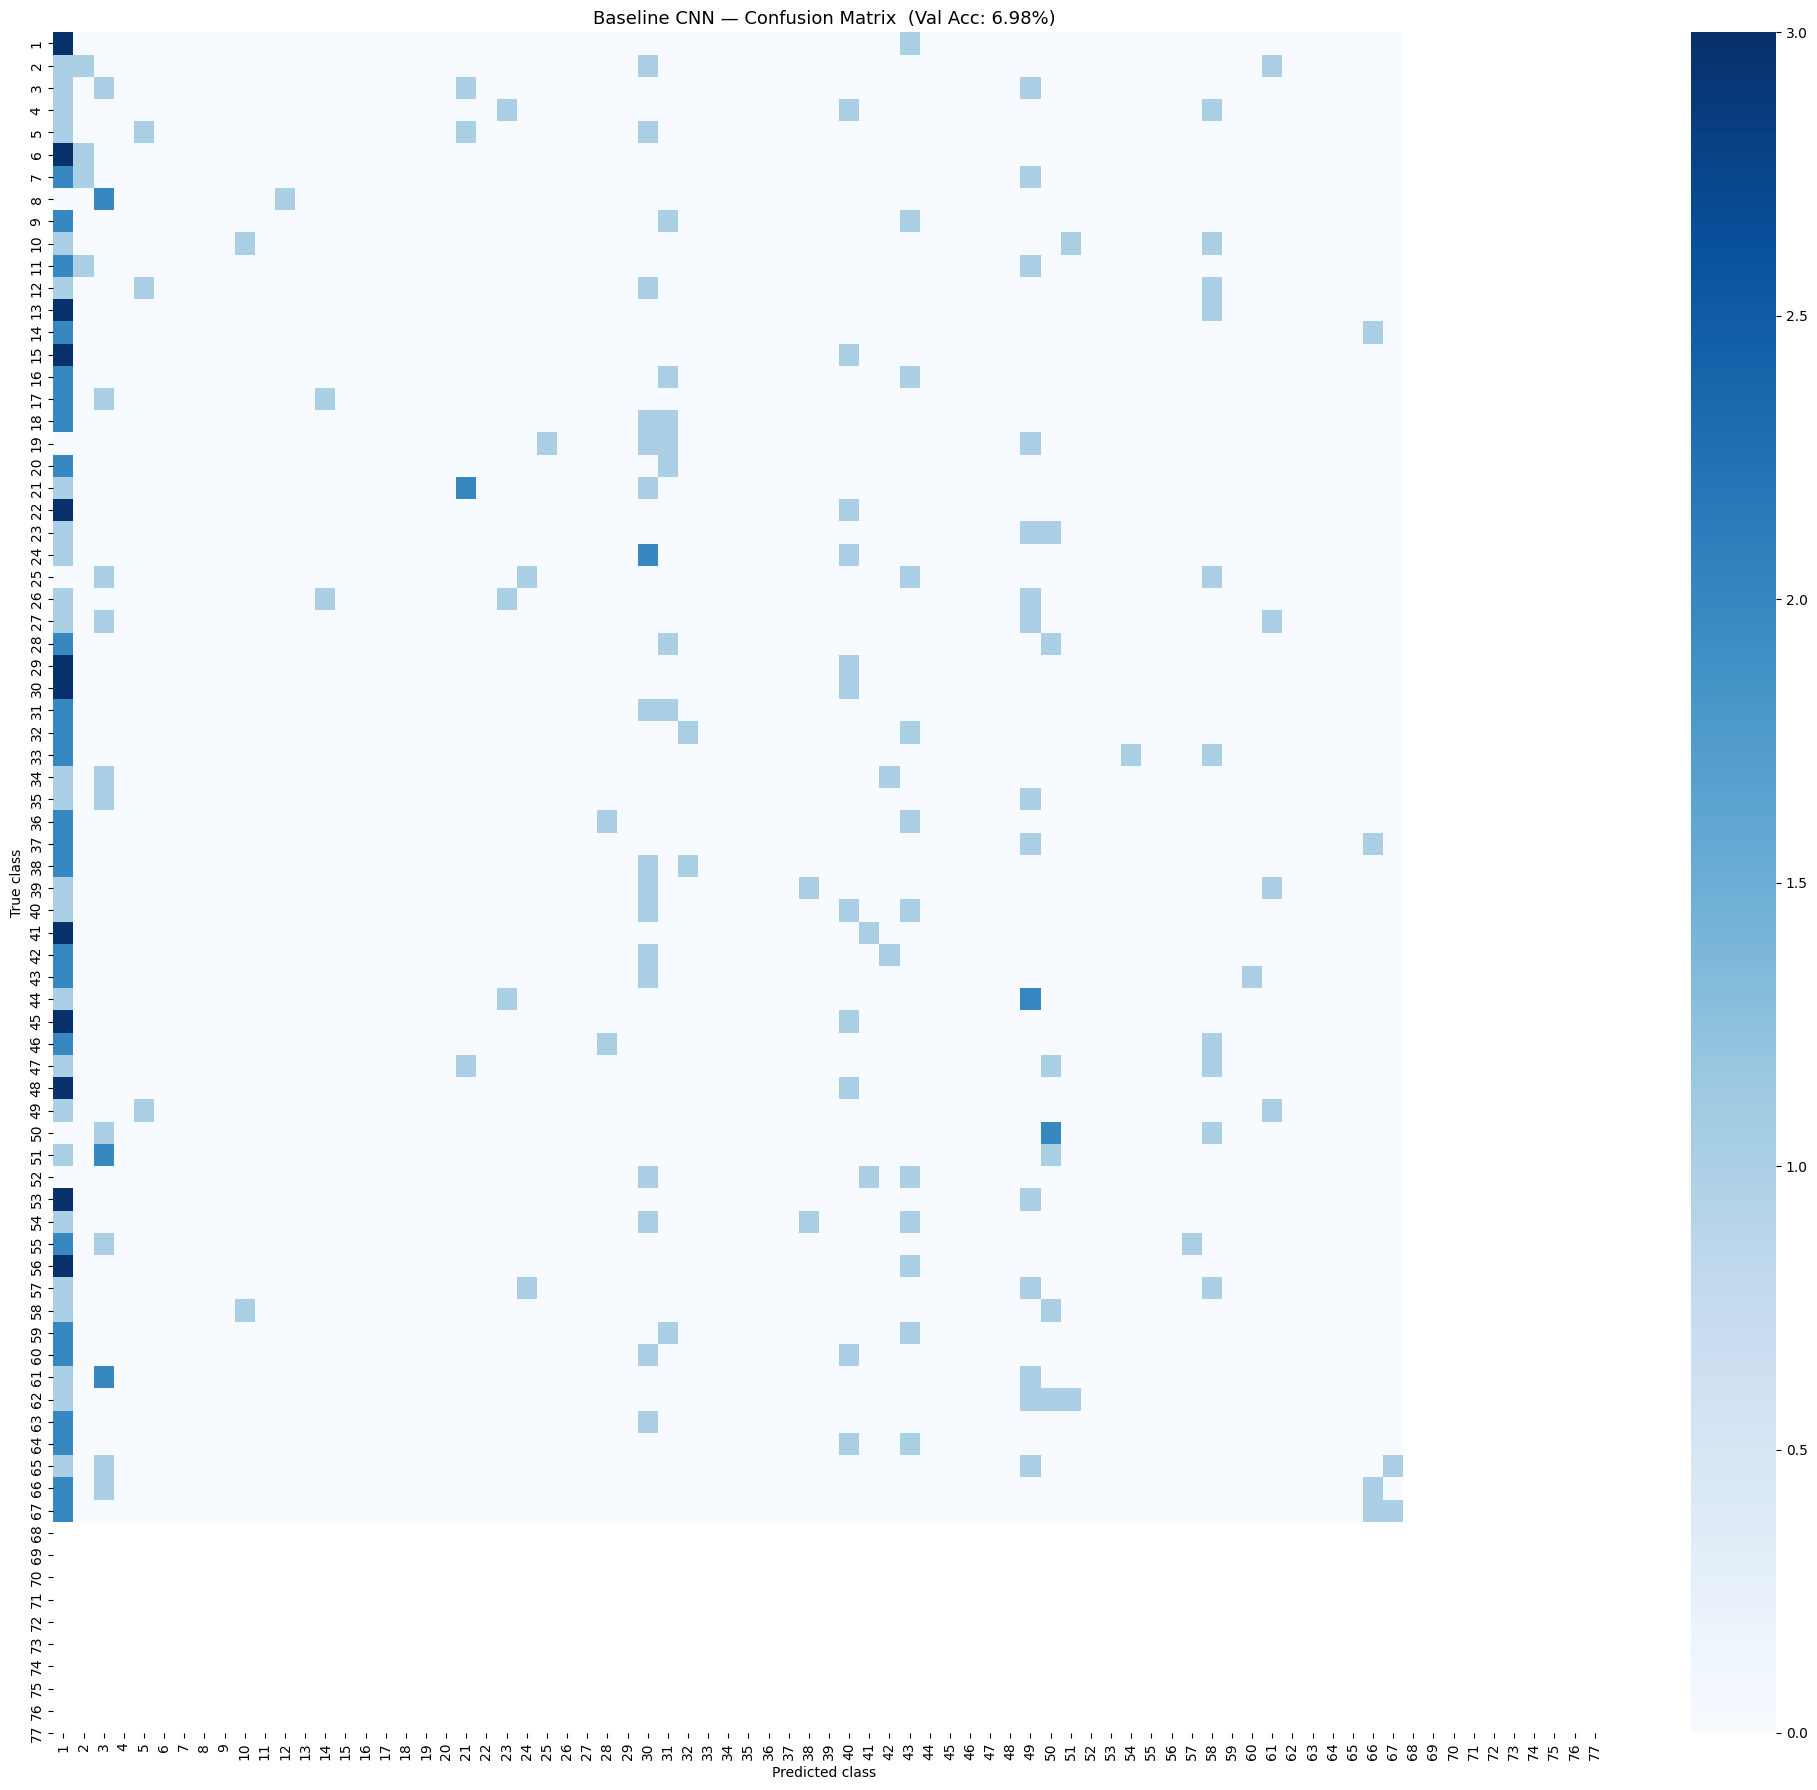

Saved: /content/drive/MyDrive/KSL_DL2026/results/figures/02_baseline_cnn_confusion.png


In [12]:
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=range(1, 78), yticklabels=range(1, 78))
plt.title(f'Baseline CNN — Confusion Matrix  (Val Acc: {best_val_acc:.2f}%)', fontsize=13)
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
path = f"{config.RESULTS_FIGS}/02_baseline_cnn_confusion.png"
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

# Log Results

Results are appended to a shared CSV log file so 고동우 can track all experiments in one place.
The ablation table in the README should be updated with `best_val_acc` after this cell runs.

In [13]:
row = {
    'experiment':        '02_baseline_cnn',
    'date':              datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model':             'VGG16 frozen + FC head',
    'temporal_modeling': False,
    'augmentation':      False,
    'transfer_learning': 'ImageNet pretrained (frozen backbone)',
    'train_signers':     '00-15',
    'val_signers':       '16-19',
    'num_classes':       config.NUM_CLASSES,
    'frame_used':        f'middle (index {config.NUM_FRAMES // 2})',
    'batch_size':        config.BATCH_SIZE,
    'learning_rate':     config.LEARNING_RATE,
    'best_val_acc':      round(best_val_acc, 2),
    'epochs_run':        len(history['val_acc']),
    'notes':             'Single frame only. Naive baseline — no temporal modeling.'
}

log_path = f"{config.RESULTS_LOGS}/02_baseline_cnn_log.csv"
write_header = not os.path.exists(log_path)
with open(log_path, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print("Results logged:")
for k, v in row.items():
    print(f"  {k}: {v}")
print(f"\nSaved to: {log_path}")

Results logged:
  experiment: 02_baseline_cnn
  date: 2026-04-15 07:43
  model: VGG16 frozen + FC head
  temporal_modeling: False
  augmentation: False
  transfer_learning: ImageNet pretrained (frozen backbone)
  train_signers: 00-15
  val_signers: 16-19
  num_classes: 77
  frame_used: middle (index 8)
  batch_size: 32
  learning_rate: 0.001
  best_val_acc: 6.98
  epochs_run: 31
  notes: Single frame only. Naive baseline — no temporal modeling.

Saved to: /content/drive/MyDrive/KSL_DL2026/results/logs/02_baseline_cnn_log.csv


# Summary

Update the **ablation table** in the README with the `best_val_acc` printed below, then hand off to Marcello for notebook 03.

In [14]:
print("=" * 55)
print("  BASELINE CNN COMPLETE")
print("=" * 55)
print(f"  Best val accuracy  : {best_val_acc:.2f}%")
print(f"  Checkpoint         : {config.CKPT_BASELINE}")
print(f"  Curves             : results/figures/02_baseline_cnn_curves.png")
print(f"  Confusion matrix   : results/figures/02_baseline_cnn_confusion.png")
print(f"  Log                : results/logs/02_baseline_cnn_log.csv")
print()
print("  Limitation demonstrated:")
print("  A single frame cannot capture sign MOTION.")
print("  Signs sharing the same hand shape but differing")
print("  in movement are confused by this model.")
print("  See confusion matrix for specific class pairs.")
print("=" * 55)

  BASELINE CNN COMPLETE
  Best val accuracy  : 6.98%
  Checkpoint         : /content/drive/MyDrive/KSL_DL2026/models/checkpoints/baseline_cnn.pth
  Curves             : results/figures/02_baseline_cnn_curves.png
  Confusion matrix   : results/figures/02_baseline_cnn_confusion.png
  Log                : results/logs/02_baseline_cnn_log.csv

  Limitation demonstrated:
  A single frame cannot capture sign MOTION.
  Signs sharing the same hand shape but differing
  in movement are confused by this model.
  See confusion matrix for specific class pairs.

  --> Next: 03_CNN_LSTM.ipynb (Marcello)
      Full 16-frame sequence + LSTM temporal model
